In [1]:
import os

import numpy as np
import pandas as pd
pd.options.display.max_columns = None

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("results/combinations.csv")
# data["num_used_col"] = data["used_col"].apply(lambda x: len(x.split(',')))
data.tail()

,used_col,subset,model,auc_score,accuracy,sensitivity,specificity
884,"US_citizenship,education_level,num_familiy,mar...",0,MLP,0.601794,0.658646,0.450980,0.674307
885,"US_citizenship,education_level,num_familiy,mar...",0,LR,0.611542,0.605706,0.553922,0.609612
886,"US_citizenship,education_level,num_familiy,mar...",0,DT,0.551677,0.744930,0.338235,0.775601
887,"US_citizenship,education_level,num_familiy,mar...",0,RF,0.610331,0.785837,0.235294,0.827357
888,"US_citizenship,education_level,num_familiy,mar...",0,XGB,0.601675,0.686146,0.421569,0.706100


In [3]:
for i, used_col in enumerate(np.unique(data["used_col"].values)):
    avg_auc = data[data["used_col"] == used_col]["auc_score"].mean()
    avg_acc = data[data["used_col"] == used_col]["accuracy"].mean()
    avg_sen = data[data["used_col"] == used_col]["sensitivity"].mean()
    avg_spe = data[data["used_col"] == used_col]["specificity"].mean()
    
    data.loc[data.shape[0]+i] = [used_col, 0, "Average", avg_auc, avg_acc, avg_sen, avg_spe]

## Sensitivity heatmap

In [4]:
sorted_by_sens = data[data["model"] == "Average"].sort_values(by="sensitivity", ascending=False)
viz_sens_avg = data.loc[pd.concat([sorted_by_sens.head(), sorted_by_sens.tail()]).index]
viz_sens_avg

,used_col,subset,model,auc_score,accuracy,sensitivity,specificity
897,US_citizenship,0,Average,0.530582,0.254673,0.839378,0.213047
973,"US_citizenship,gender",0,Average,0.513369,0.246280,0.819328,0.203063
993,"US_citizenship,num_familiy",0,Average,0.484266,0.319796,0.710784,0.290309
1005,"US_citizenship,num_familiy,gender",0,Average,0.501471,0.340716,0.675070,0.315500
1111,num_familiy,0,Average,0.488768,0.357782,0.656551,0.336513
1009,"US_citizenship,num_familiy,marital_status",0,Average,0.551674,0.681039,0.355042,0.705625
1107,"marital_status,gender",0,Average,0.541429,0.694642,0.350840,0.720570
1089,"education_level,num_familiy,marital_status,gen...",0,Average,0.561611,0.707410,0.350140,0.734354
1127,"num_familiy,marital_status",0,Average,0.547413,0.699553,0.350140,0.725904
1095,marital_status,0,Average,0.536603,0.751082,0.287935,0.784054


In [6]:
viz_sens = pd.DataFrame(columns=viz_sens_avg.columns)
viz_sens_cols = viz_sens_avg["used_col"].values
for i, used_col in enumerate(viz_sens_cols):
    viz_sens = pd.concat([viz_sens, data[data["used_col"] == used_col]])

viz_sens["used_col"] = viz_sens["used_col"].apply(lambda x: ", ".join([y for y in x.split(",")]))
viz_sens

/var/folders/nq/5pg6whfj0w57rkk_w4tb61nm0000gn/T/ipykernel_29959/3278697811.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  viz_sens = pd.concat([viz_sens, data[data["used_col"] == used_col]])


,used_col,subset,model,auc_score,accuracy,sensitivity,specificity
0,US_citizenship,0,KNN,0.530582,0.933540,0.000000,1.000000
1,US_citizenship,0,SVM,0.530582,0.141529,0.979275,0.081889
2,US_citizenship,0,MLP,0.530582,0.141529,0.979275,0.081889
3,US_citizenship,0,LR,0.530582,0.141529,0.979275,0.081889
4,US_citizenship,0,DT,0.530582,0.141529,0.979275,0.081889
...,...,...,...,...,...,...,...
24,marital_status,0,LR,0.529200,0.555441,0.523316,0.557728
25,marital_status,0,DT,0.532764,0.748967,0.305699,0.780524
26,marital_status,0,RF,0.532764,0.748967,0.305699,0.780524
27,marital_status,0,XGB,0.532764,0.748967,0.305699,0.780524


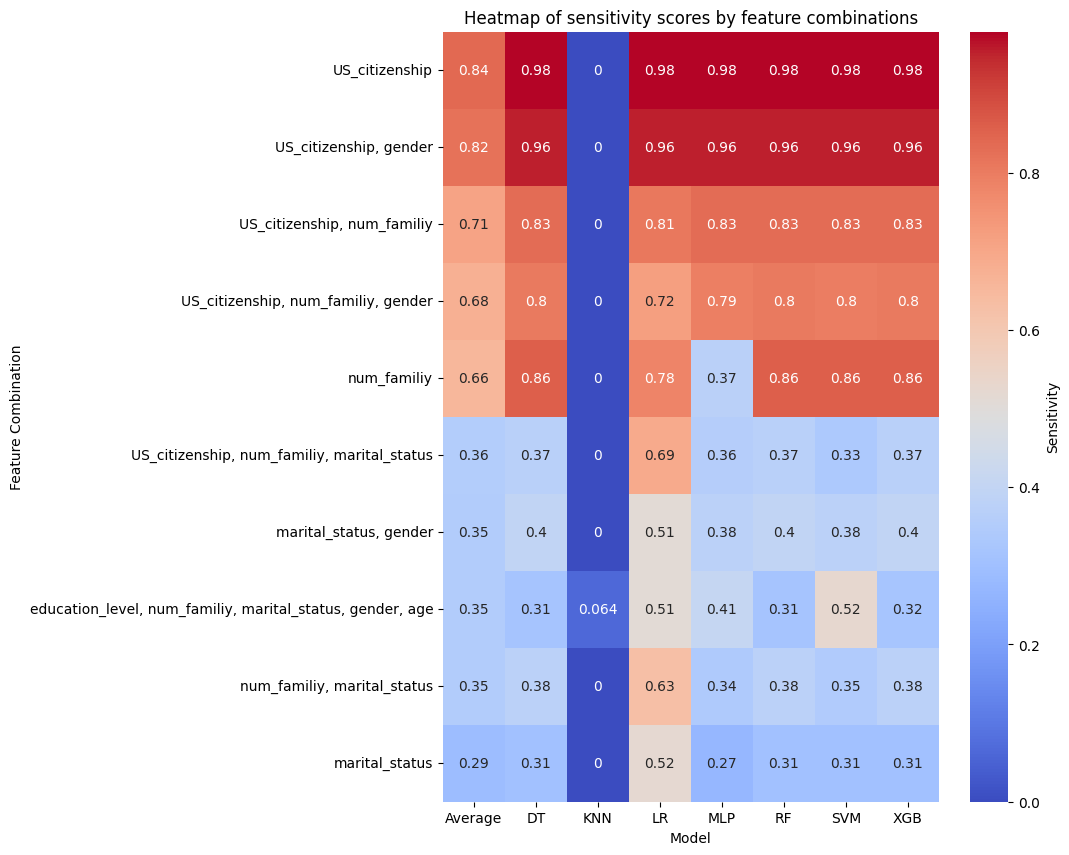

In [7]:
heatmap_data = viz_sens.pivot_table(values='sensitivity', index='used_col', columns='model').sort_values(by="Average", ascending=False)
plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar_kws={'label': 'Sensitivity'})
plt.title('Heatmap of sensitivity scores by feature combinations')
plt.ylabel('Feature Combination')
plt.xlabel('Model')
plt.show()

## AUC heatmap

In [4]:
sorted_by_auc = data[data["model"] == "Average"].sort_values(by="auc_score", ascending=False)
viz_auc_avg = data.loc[pd.concat([sorted_by_auc.head(), sorted_by_auc.tail()]).index]
viz_auc_avg

,used_col,subset,model,auc_score,accuracy,sensitivity,specificity
1025,age,0,Average,0.618865,0.665437,0.505551,0.676819
1001,"US_citizenship,num_familiy,PIR,gender,age",0,Average,0.606643,0.646614,0.489496,0.658463
997,"US_citizenship,num_familiy,PIR,age",0,Average,0.602164,0.652998,0.467087,0.667019
1119,"num_familiy,PIR,gender,age",0,Average,0.601646,0.643029,0.484594,0.654978
1063,"education_level,num_familiy,PIR,age",0,Average,0.601587,0.654913,0.474790,0.668497
1005,"US_citizenship,num_familiy,gender",0,Average,0.501471,0.340716,0.675070,0.315500
1123,"num_familiy,gender",0,Average,0.489306,0.472966,0.507003,0.470399
1111,num_familiy,0,Average,0.488768,0.357782,0.656551,0.336513
1091,gender,0,Average,0.484408,0.494097,0.464841,0.496180
993,"US_citizenship,num_familiy",0,Average,0.484266,0.319796,0.710784,0.290309


In [5]:
viz_auc = pd.DataFrame(columns=viz_auc_avg.columns)
viz_auc_cols = viz_auc_avg["used_col"].values
for i, used_col in enumerate(viz_auc_cols):
    viz_auc = pd.concat([viz_auc, data[data["used_col"] == used_col]])

viz_auc["used_col"] = viz_auc["used_col"].apply(lambda x: ", ".join([y for y in x.split(",")]))
viz_auc

/var/folders/nq/5pg6whfj0w57rkk_w4tb61nm0000gn/T/ipykernel_30174/2204127530.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  viz_auc = pd.concat([viz_auc, data[data["used_col"] == used_col]])


,used_col,subset,model,auc_score,accuracy,sensitivity,specificity
42,age,0,KNN,0.554631,0.933540,0.000000,1.000000
43,age,0,SVM,0.630231,0.591942,0.611399,0.590557
44,age,0,MLP,0.639069,0.622245,0.606218,0.623386
45,age,0,LR,0.639069,0.591942,0.611399,0.590557
46,age,0,DT,0.622237,0.639463,0.569948,0.644412
...,...,...,...,...,...,...,...
59,"US_citizenship, num_familiy",0,LR,0.488087,0.243039,0.808824,0.200370
60,"US_citizenship, num_familiy",0,DT,0.476895,0.213132,0.833333,0.166359
61,"US_citizenship, num_familiy",0,RF,0.476895,0.213132,0.833333,0.166359
62,"US_citizenship, num_familiy",0,XGB,0.476895,0.213132,0.833333,0.166359


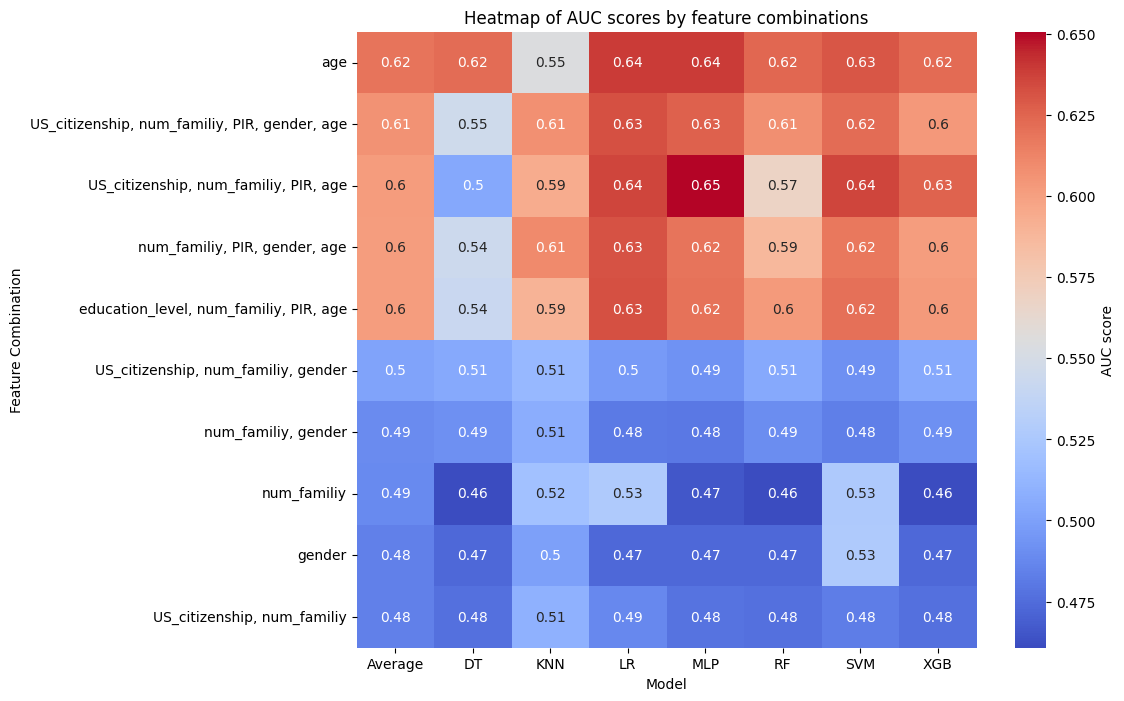

In [ ]:
heatmap_data = viz_auc.pivot_table(values='auc_score', index='used_col', columns='model').sort_values(by="Average", ascending=False)
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', cbar_kws={'label': 'AUC score'})
plt.title('Heatmap of AUC scores by feature combinations')
plt.ylabel('Feature Combination')
plt.xlabel('Model')
plt.show()